In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
       df = pd.read_csv('../data/cleaned_telco_churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df = df.drop('customerID', axis=1)

In [6]:
df.shape


(7043, 20)

In [7]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [8]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [10]:
df['gender'] = df['gender'].map({
    'Male': 1,
    'Female': 0
})

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0
    })

In [11]:
df[['gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn']].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [12]:
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [13]:
df.shape


(7043, 31)

In [14]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [15]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [16]:
df.shape


(7043, 31)

In [17]:
X.shape


(7043, 30)

In [18]:
y.shape


(7043,)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model = LogisticRegression(max_iter=1000)

In [22]:
model.fit(X_train, y_train)

C:\Users\hp 1040\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_test, y_pred)

0.8048261178140526

In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
confusion_matrix(y_test, y_pred)

array([[924, 111],
       [164, 210]])

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf = RandomForestClassifier(
    random_state=42
)

In [31]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [32]:
rf_pred = rf.predict(X_test)

In [33]:
accuracy_score(y_test, rf_pred)

0.78708303761533

In [34]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [35]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, rf_pred)

array([[926, 109],
       [191, 183]])

In [36]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

In [37]:
coef_df.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
11,InternetService_Fiber optic,0.764561
28,PaymentMethod_Electronic check,0.387446
6,PaperlessBilling,0.377625
10,MultipleLines_Yes,0.279504
24,StreamingMovies_Yes,0.219640
22,StreamingTV_Yes,0.217265
9,MultipleLines_No phone service,0.169783
1,SeniorCitizen,0.145127
29,PaymentMethod_Mailed check,0.081703
2,Partner,0.028870


In [38]:
coef_df.sort_values(
    by='Coefficient'
).head(10)

,Feature,Coefficient
26,Contract_Two year,-1.332473
25,Contract_One year,-0.690857
14,OnlineSecurity_Yes,-0.433320
5,PhoneService,-0.408719
20,TechSupport_Yes,-0.384167
3,Dependents,-0.219688
16,OnlineBackup_Yes,-0.179490
15,OnlineBackup_No internet service,-0.115607
17,DeviceProtection_No internet service,-0.115607
19,TechSupport_No internet service,-0.115607


In [39]:
import joblib

joblib.dump(
    model,
    '../models/logistic_regression.pkl'
)

['../models/logistic_regression.pkl']

## Conclusion

The customer churn prediction model was developed using the Telco Customer Churn dataset. After preprocessing and feature engineering, Logistic Regression and Random Forest models were trained and evaluated.

Logistic Regression achieved an accuracy of 80% and outperformed Random Forest in terms of recall and F1-score for churn prediction.

Feature importance analysis revealed that Fiber Optic Internet, Electronic Check payment method, and Paperless Billing were associated with higher churn risk. In contrast, customers with One-Year and Two-Year contracts, Online Security, and Tech Support services were significantly less likely to churn.

Based on these findings, the company should focus on encouraging long-term contracts, improving retention strategies for Fiber Optic users, and promoting value-added services such as Online Security and Tech Support.


In [40]:
import joblib

joblib.dump(
    model,
    '../models/logistic_regression.pkl'
)

['../models/logistic_regression.pkl']

In [41]:
import os

os.listdir('../models')

['logistic_regression.pkl']

# SHAP Explainability

In [42]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import shap

In [44]:
import sys
print(sys.executable)

C:\Users\hp 1040\AppData\Local\Programs\Python\Python312\python.exe


In [45]:
!where python

C:\Program Files\Python314\python.exe
C:\Users\hp 1040\AppData\Local\Programs\Python\Python312\python.exe
C:\Users\hp 1040\AppData\Local\Microsoft\WindowsApps\python.exe


In [46]:
import sys

!{sys.executable} -m pip install shap

'C:\Users\hp' is not recognized as an internal or external command,
operable program or batch file.


In [47]:
import sys

python_path = f'"{sys.executable}"'

!{python_path} -m pip install shap


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\hp 1040\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [48]:
import shap
print(shap.__version__)


0.52.0


In [49]:
explainer = shap.Explainer(model, X_train)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


In [50]:
shap_values = explainer(X_test)

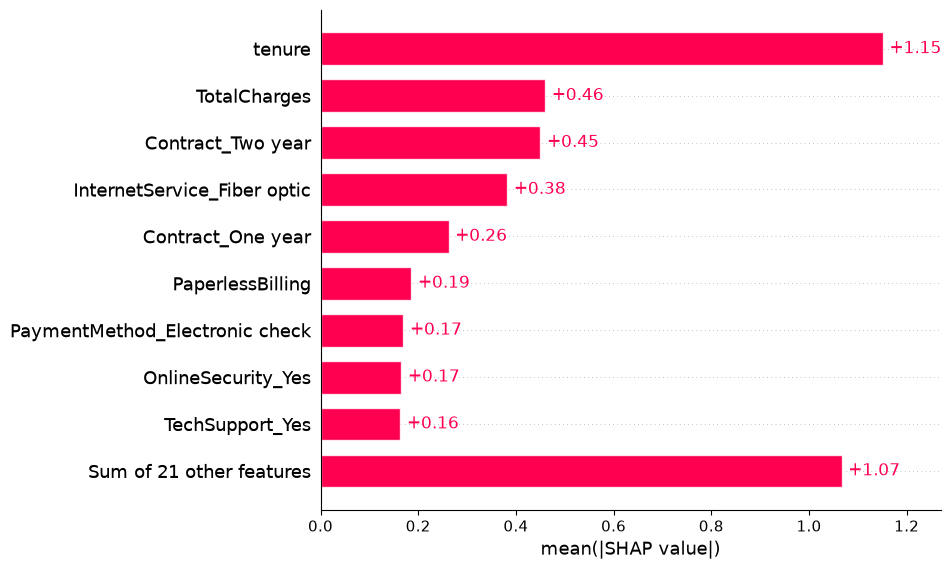

In [51]:
shap.plots.bar(shap_values)

SHAP explainability analysis revealed that customer tenure was the most influential feature affecting churn predictions, followed by Total Charges, Contract Type, and Fiber Optic Internet Service.

Customers with shorter tenure and less commitment to long-term contracts exhibited higher churn risk, while long-term customers were significantly more likely to remain with the company.

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

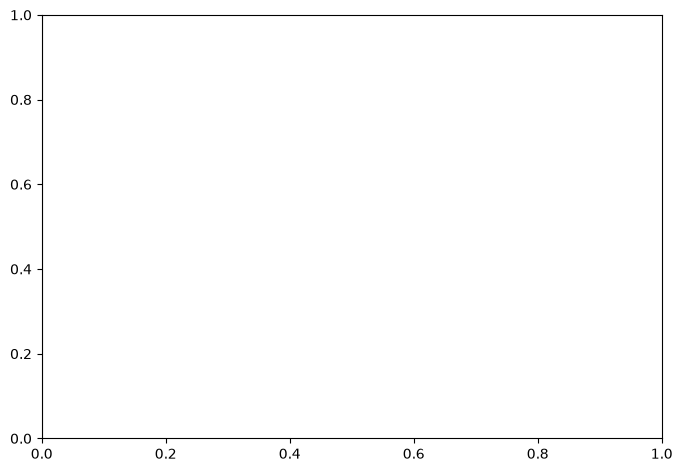

In [53]:
shap.plots.beeswarm(shap_values)

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

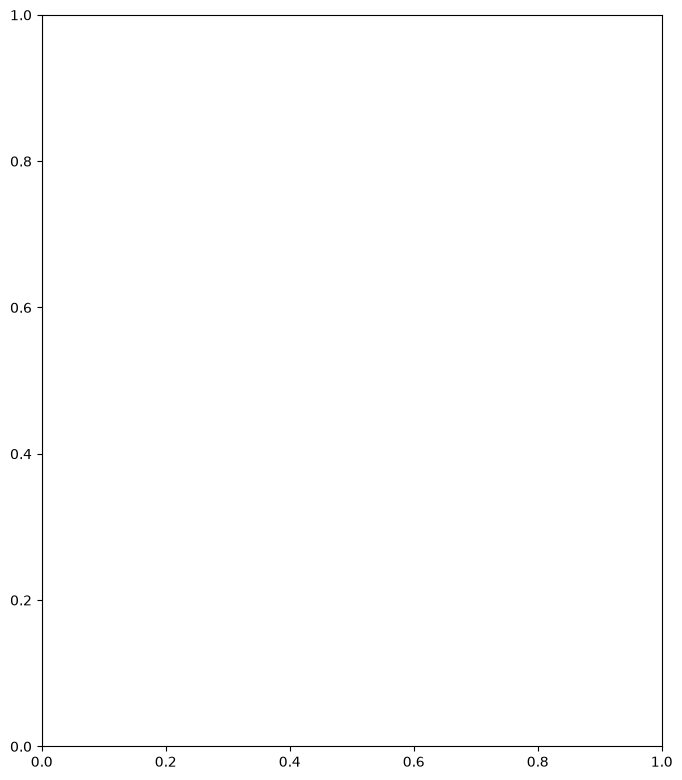

In [54]:
shap.summary_plot(
    shap_values.values,
    X_test
)

In [55]:
type(shap_values)

shap._explanation.Explanation

In [56]:
type(shap_values.values)

numpy.ndarray

In [57]:
shap_values.values.dtype

dtype('O')

In [58]:
shap_values.values.shape

(1409, 30)

In [59]:
X_test.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [60]:
X_train_num = X_train.astype(float)
X_test_num = X_test.astype(float)

In [61]:
explainer = shap.Explainer(model, X_train_num)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


In [62]:
shap_values = explainer(X_test_num)

In [63]:
shap_values.values.dtype

dtype('float64')

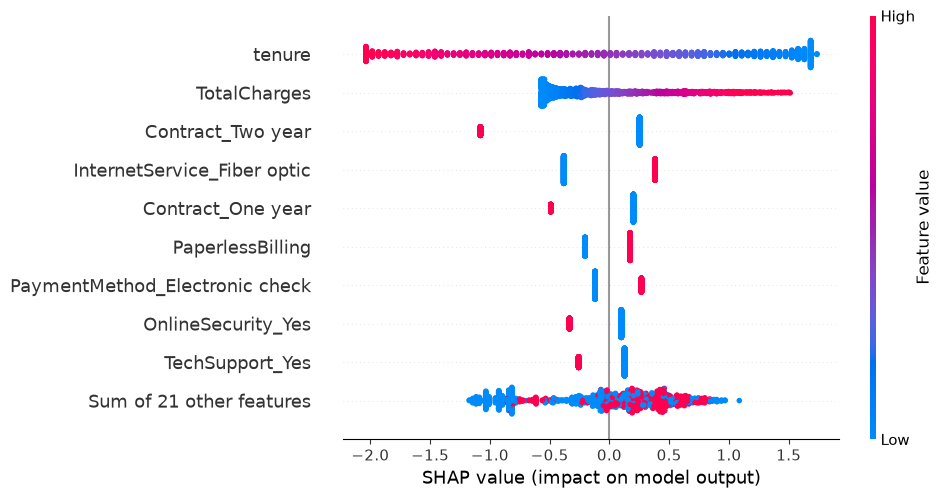

In [64]:
shap.plots.beeswarm(shap_values)

In [65]:
y_prob = model.predict_proba(X_test)[:, 1]

In [66]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8426154124363845

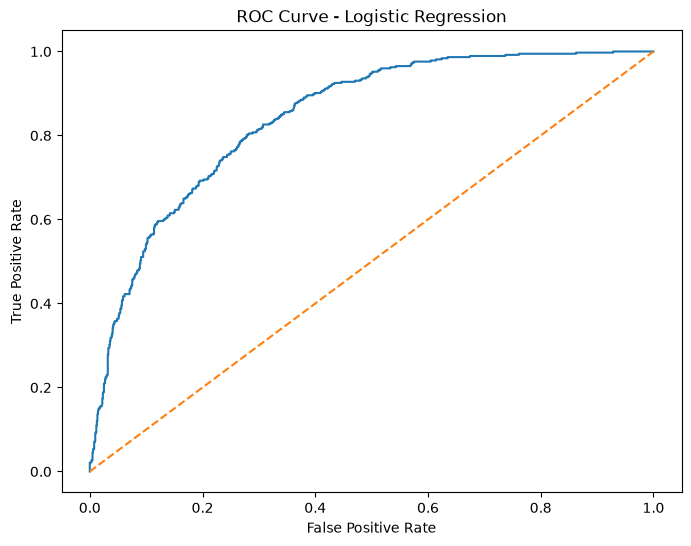

In [67]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.show()

In [68]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 5.1 MB/s eta 0:00:14
    --------------------------------------- 1.6/69.5 MB 4.6 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 4.4 MB/s eta 0:00:16
   - -------------------------------------- 2.9/69.5 MB 3.5 MB/s eta 0:00:19
   - -------------------------------------- 3.1/69.5 MB 3.4 MB/s eta 0:00:20
   -- ------------------------------------- 4.2/69.5 MB 3.4 MB/s eta 0:00:20
   --- ------------------------------------ 5.5/69.5 MB 3.8 MB/s eta 0:00:17
   ---- ----------------------------------- 7.1/69.5 MB 4.3 MB/s eta 0:00:15
   ---- ----------------------------------- 8.4/69.5 MB 4.6 MB/s eta 0:00:14
   ----- ---------------------------------- 10.2/69.5 MB 4.9 MB/s eta 0:00:13
   ------ -


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
from xgboost import XGBClassifier


ModuleNotFoundError: No module named 'xgboost'

In [70]:
import sys
print(sys.executable)

C:\Users\hp 1040\AppData\Local\Programs\Python\Python312\python.exe


In [71]:
import sys
python_path = f'"{sys.executable}"'

!{python_path} -m pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\hp 1040\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [72]:
from xgboost import XGBClassifier

In [73]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [74]:
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
xgb_pred = xgb.predict(X_test)

In [76]:
accuracy_score(y_test, xgb_pred)

classification_report(y_test, xgb_pred)

confusion_matrix(y_test, xgb_pred)

array([[903, 132],
       [186, 188]])

In [77]:
xgb_prob = xgb.predict_proba(X_test)[:,1]

roc_auc_score(y_test, xgb_prob)

0.8185706166524582

## Model Comparison

Three machine learning models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Logistic Regression achieved the highest ROC-AUC score (0.8426) and the best balance between precision and recall.

Therefore, Logistic Regression was selected as the final model for customer churn prediction.

## Final Model Comparison

| Model | Accuracy | Recall | F1 Score | ROC-AUC |
|---------|---------|---------|---------|---------|
| Logistic Regression | 0.80 | 0.56 | 0.60 | 0.8426 |
| Random Forest | 0.79 | 0.49 | 0.55 | ~0.81 |
| XGBoost | ~0.78 | ~0.50 | ~0.56 | 0.8186 |

### Selected Model
Logistic Regression was selected as the final model because it achieved the highest ROC-AUC score and the best balance between recall and F1-score.